# Safety Metrics Design for a Content Platform

This notebook develops a comprehensive safety metrics framework for a TikTok-like short-video platform. We cover:

1. **Metric Design Principles** -- north star / guardrail / diagnostic hierarchy
2. **Core Safety Metrics** -- violation rate, precision-recall, time-to-action, recidivism
3. **Composite Safety Scoring** -- combining multiple metrics into a single actionable index
4. **Anomaly Detection** -- z-score, EWMA, and change-point methods for safety monitoring
5. **Experiment Metrics & OEC** -- Overall Evaluation Criterion and trade-off analysis
6. **Dashboard Case Study** -- end-to-end safety metrics dashboard for TikTok Integrity & Safety

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

%matplotlib inline

# Project generators
from data.generators.safety_incidents import (
    generate_incident_timeseries,
    generate_hourly_incidents,
    generate_policy_impact_timeseries,
)
from data.generators.content_moderation import generate_content_stream
from data.generators.policy_experiments import generate_friction_warning_test

# Project utilities
from utils.metrics_library import (
    violation_rate,
    precision_recall_at_threshold,
    precision_recall_curve,
    time_to_action,
    recidivism_rate,
    composite_safety_score,
    anomaly_detection_zscore,
    ewma_anomaly_detection,
    change_point_detection,
)
from utils.visualization import set_style, plot_anomaly_detection, plot_metric_tradeoff

set_style()
print('Setup complete.')

Setup complete.


---
## Block 1: Metric Design Principles

A robust safety metrics framework follows a **three-tier hierarchy**:

| Tier | Purpose | Example |
|------|---------|---------|
| **North Star** | The one metric the entire org optimizes toward | User Safety Score (low violation exposure rate) |
| **Guardrails** | Constraints that must not degrade beyond acceptable bounds | False Positive Rate, Creator Churn, Appeal Overturn Rate |
| **Diagnostics** | Drill-down metrics for root-cause analysis | Per-category violation breakdown, time-to-action, recidivism |

### Why this hierarchy matters

- **North Star** keeps the team aligned on a single outcome -- user safety.
- **Guardrails** prevent the org from gaming the north star (e.g., removing all borderline content would reduce violations but increase FPR and creator churn).
- **Diagnostics** enable root-cause investigation when the north star or guardrails move unexpectedly.

In [2]:
# Metric taxonomy table
taxonomy = pd.DataFrame([
    {"metric": "Violation Exposure Rate",   "tier": "North Star",  "definition": "Fraction of content views that are on violating content",        "direction": "lower is better",  "owner": "VP Safety"},
    {"metric": "Classifier Precision",      "tier": "Guardrail",   "definition": "TP / (TP + FP) -- accuracy of automated removals",              "direction": "higher is better", "owner": "ML Team"},
    {"metric": "Classifier Recall",         "tier": "Guardrail",   "definition": "TP / (TP + FN) -- coverage of violating content",               "direction": "higher is better", "owner": "ML Team"},
    {"metric": "False Positive Rate",       "tier": "Guardrail",   "definition": "FP / (FP + TN) -- wrongful removal rate",                      "direction": "lower is better",  "owner": "ML Team"},
    {"metric": "Creator Churn (7d)",        "tier": "Guardrail",   "definition": "Fraction of creators who stop posting within 7 days",          "direction": "lower is better",  "owner": "Creator Ops"},
    {"metric": "Appeal Overturn Rate",      "tier": "Guardrail",   "definition": "Fraction of appeals that are upheld (content restored)",       "direction": "lower is better",  "owner": "Policy Team"},
    {"metric": "Per-Category Violation Rate", "tier": "Diagnostic", "definition": "Violation rate broken down by hate/spam/nudity/etc.",           "direction": "lower is better",  "owner": "Category Leads"},
    {"metric": "Time-to-Action (p50)",      "tier": "Diagnostic",  "definition": "Median hours from content post to moderation action",          "direction": "lower is better",  "owner": "Ops Team"},
    {"metric": "Time-to-Action (p95)",      "tier": "Diagnostic",  "definition": "95th-percentile hours to moderation action",                   "direction": "lower is better",  "owner": "Ops Team"},
    {"metric": "Recidivism Rate (30d)",     "tier": "Diagnostic",  "definition": "Fraction of offenders who re-offend within 30 days",           "direction": "lower is better",  "owner": "Enforcement"},
    {"metric": "Regional Violation Heatmap", "tier": "Diagnostic", "definition": "Violation rates by region for geo-specific policy gaps",        "direction": "lower is better",  "owner": "Regional Ops"},
])

print("Safety Metrics Taxonomy")
print("=" * 120)
display(taxonomy.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

Safety Metrics Taxonomy


metric,tier,definition,direction,owner
Violation Exposure Rate,North Star,Fraction of content views that are on violating content,lower is better,VP Safety
Classifier Precision,Guardrail,TP / (TP + FP) -- accuracy of automated removals,higher is better,ML Team
Classifier Recall,Guardrail,TP / (TP + FN) -- coverage of violating content,higher is better,ML Team
False Positive Rate,Guardrail,FP / (FP + TN) -- wrongful removal rate,lower is better,ML Team
Creator Churn (7d),Guardrail,Fraction of creators who stop posting within 7 days,lower is better,Creator Ops
Appeal Overturn Rate,Guardrail,Fraction of appeals that are upheld (content restored),lower is better,Policy Team
Per-Category Violation Rate,Diagnostic,Violation rate broken down by hate/spam/nudity/etc.,lower is better,Category Leads
Time-to-Action (p50),Diagnostic,Median hours from content post to moderation action,lower is better,Ops Team
Time-to-Action (p95),Diagnostic,95th-percentile hours to moderation action,lower is better,Ops Team
Recidivism Rate (30d),Diagnostic,Fraction of offenders who re-offend within 30 days,lower is better,Enforcement


In [3]:
# Metric tree: North Star -> Guardrails -> Diagnostics
tree = """
SAFETY METRIC TREE
==================

North Star
  |-- Violation Exposure Rate  (% of views on violating content)
      |
      |-- Guardrails
      |     |-- Classifier Precision        (wrongful removals in check)
      |     |-- Classifier Recall            (violating content caught)
      |     |-- False Positive Rate          (user trust preserved)
      |     |-- Creator Churn (7d)           (creator ecosystem health)
      |     |-- Appeal Overturn Rate         (policy calibration)
      |
      |-- Diagnostics
            |-- Per-Category Breakdown
            |     |-- Hate Speech Rate
            |     |-- Misinformation Rate
            |     |-- Spam Rate
            |     |-- Nudity Rate
            |     |-- Violence Rate
            |     |-- Copyright Rate
            |
            |-- Operational Metrics
            |     |-- Time-to-Action (p50, p95)
            |     |-- Auto-Removal Rate
            |     |-- Queue Depth
            |
            |-- Behavioural Metrics
                  |-- Recidivism Rate (30d)
                  |-- Repeat Offender Concentration
                  |-- Regional Violation Heatmap
"""
print(tree)


SAFETY METRIC TREE

North Star
  |-- Violation Exposure Rate  (% of views on violating content)
      |
      |-- Guardrails
      |     |-- Classifier Precision        (wrongful removals in check)
      |     |-- Classifier Recall            (violating content caught)
      |     |-- False Positive Rate          (user trust preserved)
      |     |-- Creator Churn (7d)           (creator ecosystem health)
      |     |-- Appeal Overturn Rate         (policy calibration)
      |
      |-- Diagnostics
            |-- Per-Category Breakdown
            |     |-- Hate Speech Rate
            |     |-- Misinformation Rate
            |     |-- Spam Rate
            |     |-- Nudity Rate
            |     |-- Violence Rate
            |     |-- Copyright Rate
            |
            |-- Operational Metrics
            |     |-- Time-to-Action (p50, p95)
            |     |-- Auto-Removal Rate
            |     |-- Queue Depth
            |
            |-- Behavioural Metrics
            

---
## Block 2: Core Safety Metrics

We now compute each core metric on synthetic content-moderation data generated by `generate_content_stream()`. This simulates 50,000 content items flowing through a moderation pipeline with a calibrated ML classifier.

In [4]:
# Load content stream data
stream = generate_content_stream(n_items=50_000, seed=42)
print(f"Content stream shape: {stream.shape}")
print(f"Violation rate: {stream['is_violation'].mean():.4f}")
print(f"Unique users: {stream['user_id'].nunique():,}")
print(f"Date range: {stream['timestamp'].min().date()} to {stream['timestamp'].max().date()}")
display(stream.head())

Content stream shape: (50000, 20)
Violation rate: 0.0293
Unique users: 9,940
Date range: 2025-01-01 to 2025-03-31


,content_id,user_id,timestamp,content_type,category,violation_type,is_violation,classifier_score,classifier_prediction,true_positive,false_positive,false_negative,true_negative,reports_count,views,likes,shares,comments,moderation_action,time_to_action_hours
0,C37717,U08119,2025-01-01 00:01:43.283205226,comment,entertainment,none,False,0.0988,False,False,False,False,True,0,41,5,0,2,none,NaN
1,C10415,U03339,2025-01-01 00:03:33.566546538,live,entertainment,none,False,0.3621,False,False,False,False,True,0,315,84,11,65,none,NaN
2,C01743,U04559,2025-01-01 00:06:07.103632026,video,other,none,False,0.1622,False,False,False,False,True,0,674,143,7,32,none,NaN
3,C28792,U02195,2025-01-01 00:07:25.821928784,video,commerce,none,False,0.4056,False,False,False,False,True,0,39273,6525,176,4026,none,NaN
4,C25568,U05047,2025-01-01 00:08:03.148871405,video,entertainment,none,False,0.3934,False,False,False,False,True,0,2436,840,41,126,none,NaN


In [5]:
# Compute violation rate with 95% confidence interval
vr = violation_rate(
    violations=stream['is_violation'].values.astype(int),
    total=np.ones(len(stream), dtype=int),
)
print("Violation Rate Analysis")
print("=" * 50)
print(f"  Overall rate:       {vr['rate']:.4f}  ({vr['rate']*100:.2f}%)")
print(f"  95% CI:             [{vr['ci_lower']:.4f}, {vr['ci_upper']:.4f}]")
print(f"  Standard error:     {vr['se']:.6f}")
print(f"  Total violations:   {vr['total_violations']:,}")
print(f"  Total content:      {vr['total_content']:,}")

# Per-category violation rates
print("\nPer-Category Violation Rates:")
cat_rates = stream.groupby('category')['is_violation'].agg(['mean', 'sum', 'count'])
cat_rates.columns = ['rate', 'violations', 'total']
cat_rates = cat_rates.sort_values('rate', ascending=False)
display(cat_rates)

Violation Rate Analysis
  Overall rate:       0.0293  (2.93%)
  95% CI:             [0.0279, 0.0308]
  Standard error:     0.000755
  Total violations:   1,467
  Total content:      50,000

Per-Category Violation Rates:


,rate,violations,total
category,,,
news,0.047152,471,9989
commerce,0.041944,315,7510
other,0.025956,131,5047
entertainment,0.022453,449,19997
education,0.013544,101,7457


In [6]:
# Precision, Recall, F1, FPR at different thresholds
scores = stream['classifier_score'].values
labels = stream['is_violation'].values.astype(int)

thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
rows = []
for t in thresholds_to_check:
    result = precision_recall_at_threshold(scores, labels, threshold=t)
    rows.append(result)

threshold_df = pd.DataFrame(rows)
print("Classifier Performance at Different Thresholds")
print("=" * 80)
display(
    threshold_df[['threshold', 'precision', 'recall', 'f1', 'fpr', 'tp', 'fp', 'fn', 'tn']]
    .style.format({
        'precision': '{:.4f}', 'recall': '{:.4f}', 'f1': '{:.4f}', 'fpr': '{:.4f}',
        'threshold': '{:.1f}',
    }).hide(axis='index')
)

Classifier Performance at Different Thresholds


threshold,precision,recall,f1,fpr,tp,fp,fn,tn
0.3,0.1242,0.9455,0.2196,0.2015,1387,9778,80,38755
0.4,0.2746,0.9223,0.4231,0.0737,1353,3575,114,44958
0.5,0.5466,0.8950,0.6787,0.0224,1313,1089,154,47444
0.6,0.7684,0.8344,0.8000,0.0076,1224,369,243,48164
0.7,0.8713,0.7246,0.7912,0.0032,1063,157,404,48376
0.8,0.9033,0.5160,0.6568,0.0017,757,81,710,48452


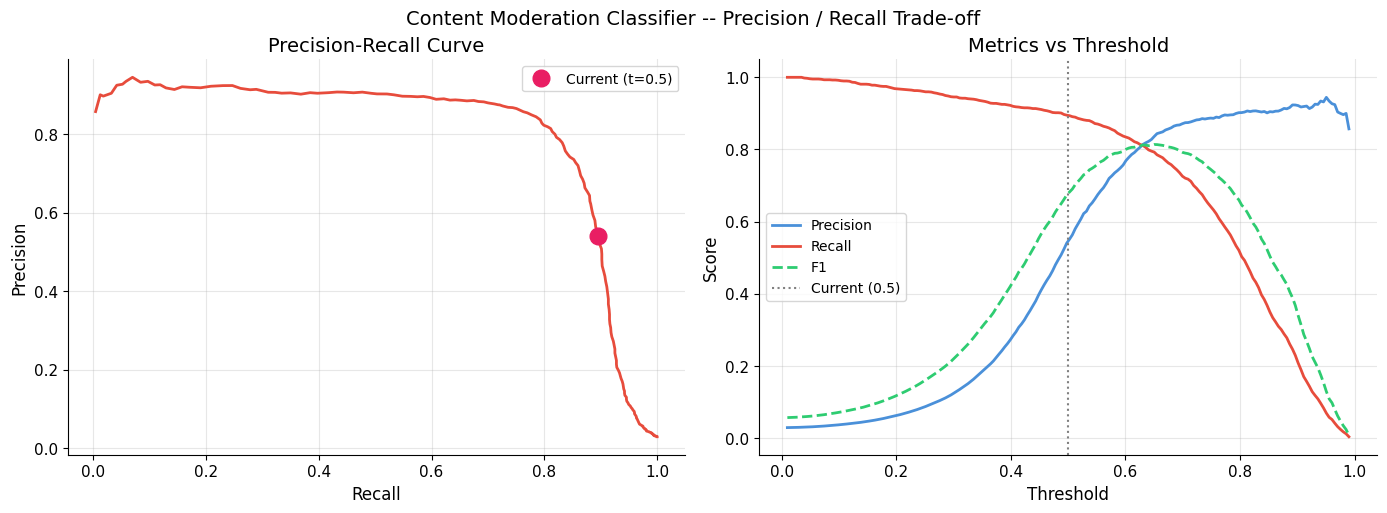


Optimal F1 threshold: 0.650
  Precision = 0.8361
  Recall    = 0.7928
  F1        = 0.8139


In [7]:
# Full precision-recall curve
pr_df = precision_recall_curve(scores, labels, n_thresholds=200)

fig = plot_metric_tradeoff(
    precision=pr_df['precision'].values,
    recall=pr_df['recall'].values,
    thresholds=pr_df['threshold'].values,
    current_threshold=0.5,
)
fig.suptitle('Content Moderation Classifier -- Precision / Recall Trade-off', fontsize=14, y=1.02)
plt.show()

# Find the optimal F1 threshold
best_idx = pr_df['f1'].idxmax()
print(f"\nOptimal F1 threshold: {pr_df.loc[best_idx, 'threshold']:.3f}")
print(f"  Precision = {pr_df.loc[best_idx, 'precision']:.4f}")
print(f"  Recall    = {pr_df.loc[best_idx, 'recall']:.4f}")
print(f"  F1        = {pr_df.loc[best_idx, 'f1']:.4f}")

Time-to-Action Analysis
  Actioned items:     2,484
  Mean:               1.52 hours
  Median (p50):       0.63 hours
  p75:                1.33 hours
  p90:                2.76 hours
  p95:                4.89 hours
  p99:                17.83 hours

SLA Compliance:
  p50 target=1.0h  actual=0.63h  met=True
  p95 target=24.0h  actual=4.89h  met=True


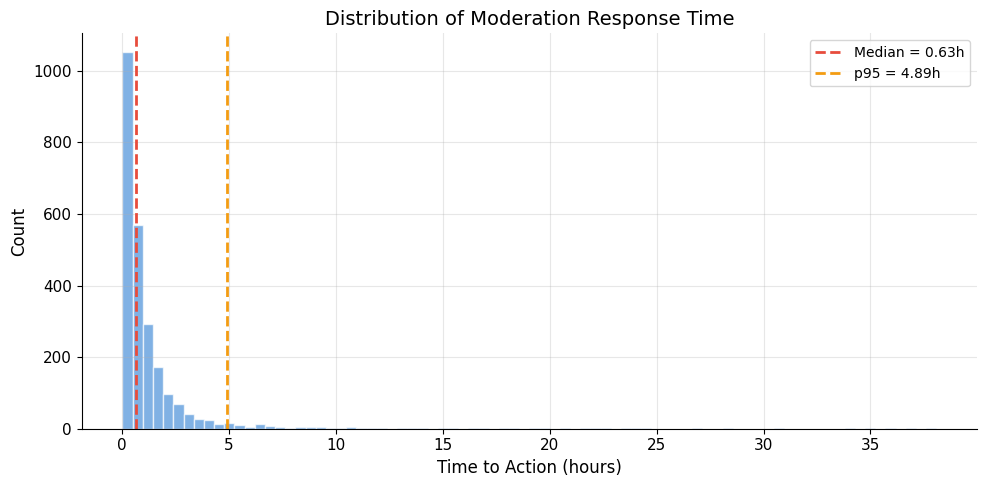

In [8]:
# Time-to-action statistics
action_times = stream['time_to_action_hours'].dropna().values

tta_stats = time_to_action(
    action_times,
    targets={"p50": 1.0, "p95": 24.0}
)

print("Time-to-Action Analysis")
print("=" * 50)
print(f"  Actioned items:     {tta_stats['n']:,}")
print(f"  Mean:               {tta_stats['mean']:.2f} hours")
print(f"  Median (p50):       {tta_stats['p50']:.2f} hours")
print(f"  p75:                {tta_stats['p75']:.2f} hours")
print(f"  p90:                {tta_stats['p90']:.2f} hours")
print(f"  p95:                {tta_stats['p95']:.2f} hours")
print(f"  p99:                {tta_stats['p99']:.2f} hours")
print()
print("SLA Compliance:")
print(f"  p50 target={tta_stats['sla_p50_target']}h  actual={tta_stats['sla_p50_actual']:.2f}h  met={tta_stats['sla_p50_met']}")
print(f"  p95 target={tta_stats['sla_p95_target']}h  actual={tta_stats['sla_p95_actual']:.2f}h  met={tta_stats['sla_p95_met']}")

# Distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(action_times[action_times < 50], bins=80, color='#4A90D9', alpha=0.7, edgecolor='white')
ax.axvline(tta_stats['p50'], color='#E74C3C', linestyle='--', linewidth=2, label=f"Median = {tta_stats['p50']:.2f}h")
ax.axvline(tta_stats['p95'], color='#F39C12', linestyle='--', linewidth=2, label=f"p95 = {tta_stats['p95']:.2f}h")
ax.set_xlabel('Time to Action (hours)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Moderation Response Time')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Recidivism rate -- build user-violation events from the content stream
violations_df = stream[stream['is_violation']].copy()
violations_df = violations_df[['user_id', 'timestamp', 'violation_type', 'content_id']].copy()
print(f"Total violation events: {len(violations_df):,}")
print(f"Unique offending users: {violations_df['user_id'].nunique():,}")

recid = recidivism_rate(
    user_violations=violations_df,
    user_col='user_id',
    time_col='timestamp',
    window_days=30,
)

print("\nRecidivism Analysis (30-day window)")
print("=" * 50)
print(f"  Total offenders:          {recid['total_offenders']:,}")
print(f"  Repeat offenders:         {recid['repeat_offenders']:,}")
print(f"  Recidivists in window:    {recid['recidivists_in_window']:,}")
print(f"  Recidivism rate:          {recid['recidivism_rate']:.4f}  ({recid['recidivism_rate']*100:.1f}%)")
print(f"  Avg violations/offender:  {recid['avg_violations_per_offender']:.2f}")
print(f"  Max violations (one user): {recid['max_violations']}")

Total violation events: 1,467
Unique offending users: 1,365

Recidivism Analysis (30-day window)
  Total offenders:          1,365
  Repeat offenders:         100
  Recidivists in window:    64
  Recidivism rate:          0.0469  (4.7%)
  Avg violations/offender:  1.07
  Max violations (one user): 3


---
## Block 3: Composite Safety Scoring

No single metric tells the full story. A platform could achieve 99% recall by removing everything (destroying precision and creator trust), or minimize FPR by removing nothing (ignoring violations). A **composite safety score** balances these tensions into one actionable number.

The `composite_safety_score()` function:
1. Normalizes each metric to [0, 1] (inverting "lower is better" metrics)
2. Applies user-defined weights
3. Returns weighted average + interpretation tier (excellent / good / needs_improvement / critical)

In [10]:
# Compute individual metrics from the content stream
perf_at_05 = precision_recall_at_threshold(scores, labels, threshold=0.5)

metrics_dict = {
    "violation_rate": vr['rate'],
    "precision": perf_at_05['precision'],
    "recall": perf_at_05['recall'],
    "f1": perf_at_05['f1'],
    "fpr": perf_at_05['fpr'],
    "time_to_action": tta_stats['p50'] / 24.0,  # normalize to fraction of a day
    "recidivism_rate": recid['recidivism_rate'],
}

print("Individual Safety Metrics")
print("=" * 50)
for k, v in metrics_dict.items():
    print(f"  {k:25s} = {v:.4f}")

Individual Safety Metrics
  violation_rate            = 0.0293
  precision                 = 0.5466
  recall                    = 0.8950
  f1                        = 0.6787
  fpr                       = 0.0224
  time_to_action            = 0.0262
  recidivism_rate           = 0.0469


In [11]:
# Build composite safety scores with different weight schemes
weight_schemes = {
    "Equal Weights": {k: 1.0 for k in metrics_dict},
    "Safety-First": {
        "violation_rate": 3.0, "recall": 2.5, "precision": 1.5,
        "f1": 1.0, "fpr": 2.0, "time_to_action": 1.5, "recidivism_rate": 2.0,
    },
    "Creator-Friendly": {
        "violation_rate": 1.5, "recall": 1.0, "precision": 3.0,
        "f1": 1.0, "fpr": 3.0, "time_to_action": 1.0, "recidivism_rate": 1.0,
    },
    "Ops-Focused": {
        "violation_rate": 1.0, "recall": 1.0, "precision": 1.0,
        "f1": 1.0, "fpr": 1.0, "time_to_action": 3.0, "recidivism_rate": 3.0,
    },
}

results_rows = []
for scheme_name, weights in weight_schemes.items():
    result = composite_safety_score(metrics_dict, weights)
    results_rows.append({
        "Weighting Scheme": scheme_name,
        "Composite Score": result['composite_score'],
        "Interpretation": result['interpretation'],
    })

results_df = pd.DataFrame(results_rows)
print("Composite Safety Scores Under Different Weight Schemes")
print("=" * 65)
display(results_df.style.format({'Composite Score': '{:.4f}'}).hide(axis='index'))

Composite Safety Scores Under Different Weight Schemes


Weighting Scheme,Composite Score,Interpretation
Equal Weights,0.8565,good
Safety-First,0.8867,good
Creator-Friendly,0.8286,good
Ops-Focused,0.8954,good


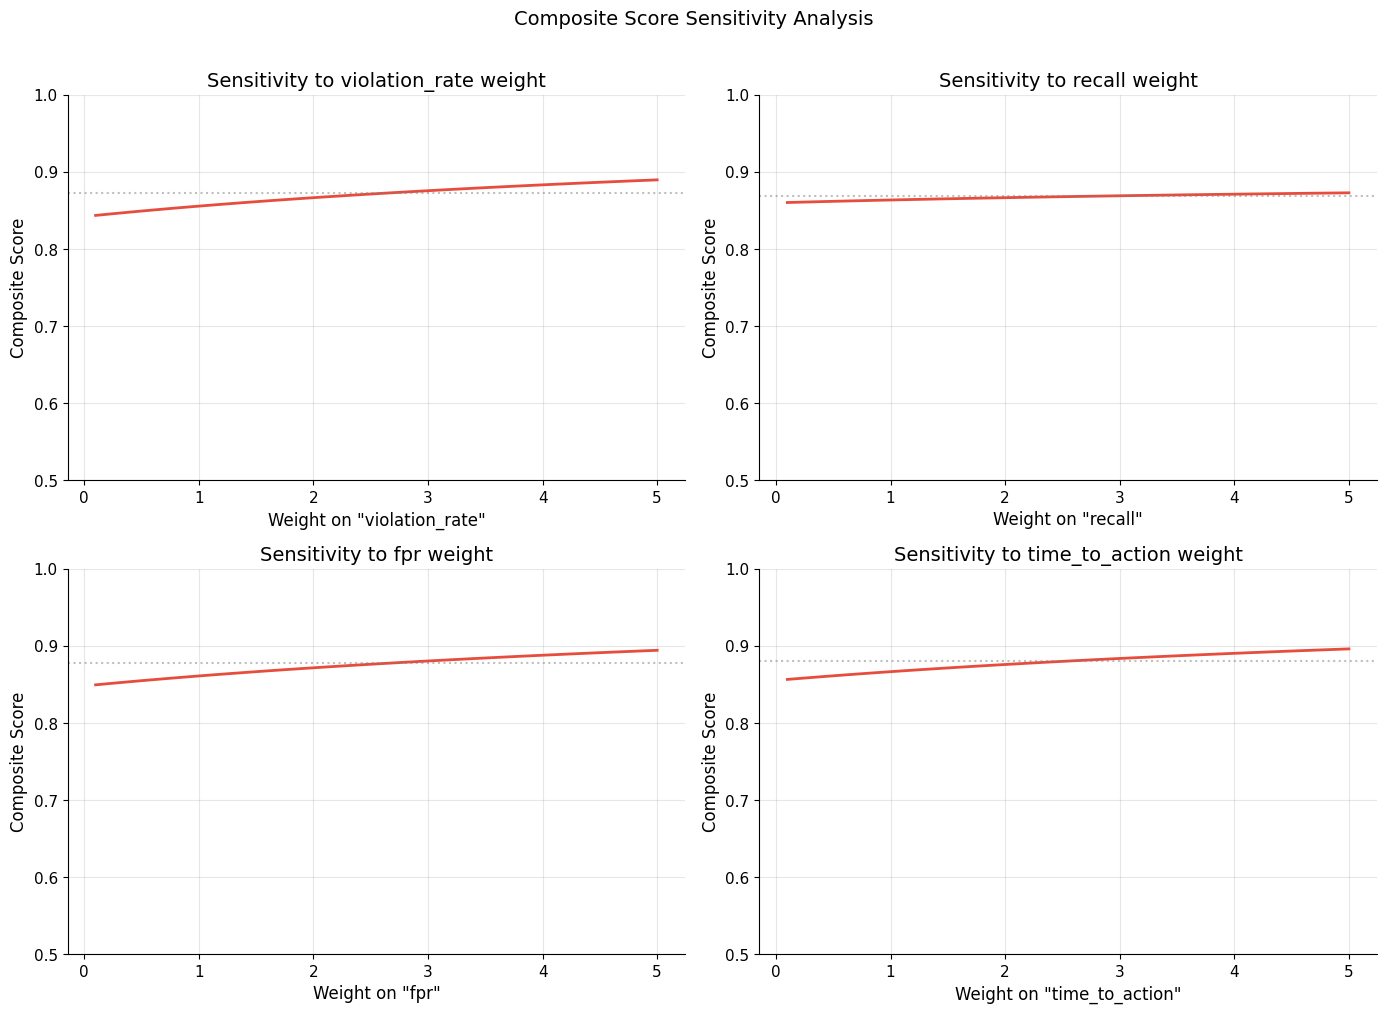

Interpretation: Metrics with steeper curves have more influence on the composite score.
If the score barely moves when you change a weight, that metric has low leverage.


In [12]:
# Sensitivity analysis: how does composite score change as we vary one weight?
base_weights = {
    "violation_rate": 2.0, "recall": 2.0, "precision": 1.5,
    "f1": 1.0, "fpr": 1.5, "time_to_action": 1.0, "recidivism_rate": 1.5,
}

sweep_metrics = ["violation_rate", "recall", "fpr", "time_to_action"]
sweep_range = np.linspace(0.1, 5.0, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric_name in enumerate(sweep_metrics):
    composite_scores = []
    for w in sweep_range:
        w_copy = base_weights.copy()
        w_copy[metric_name] = w
        cs = composite_safety_score(metrics_dict, w_copy)
        composite_scores.append(cs['composite_score'])

    axes[i].plot(sweep_range, composite_scores, linewidth=2, color='#E74C3C')
    axes[i].axhline(composite_scores[len(composite_scores)//2], color='gray', linestyle=':', alpha=0.5)
    axes[i].set_xlabel(f'Weight on "{metric_name}"')
    axes[i].set_ylabel('Composite Score')
    axes[i].set_title(f'Sensitivity to {metric_name} weight')
    axes[i].set_ylim(0.5, 1.0)

fig.suptitle('Composite Score Sensitivity Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretation: Metrics with steeper curves have more influence on the composite score.")
print("If the score barely moves when you change a weight, that metric has low leverage.")

---
## Block 4: Anomaly Detection for Safety Monitoring

Safety metrics require real-time monitoring with automated alerting. We compare three anomaly detection methods:

1. **Z-Score** (rolling window) -- simple, robust for stationary series. Flags points > k standard deviations from the rolling mean.
2. **EWMA** (Exponentially Weighted Moving Average) -- reacts faster to recent changes, better for non-stationary series.
3. **Change-Point Detection** (CUSUM) -- identifies structural breaks in the time series (e.g., policy changes, classifier degradation).

We test these on synthetic daily incident data with four injected anomalies:
- Day 60-62: Hate-speech spike (3x baseline)
- Day 150-180: Gradual spam drift (linear ramp to 2x)
- Day 250-255: Holiday seasonal break (+40%)
- Day 320: Single-day violence spike (4x)

In [13]:
# Load daily incident time series (365 days, with injected anomalies)
daily = generate_incident_timeseries(n_days=365, seed=42)
print(f"Daily incident data shape: {daily.shape}")
print(f"Date range: {daily['date'].min().date()} to {daily['date'].max().date()}")
print(f"Anomaly days: {daily['is_anomaly'].sum()}")
print(f"\nAnomaly breakdown:")
display(daily[daily['is_anomaly']].groupby('anomaly_type').size().rename('count').to_frame())

Daily incident data shape: (365, 19)
Date range: 2025-01-01 to 2025-12-31
Anomaly days: 40

Anomaly breakdown:


,count
anomaly_type,
drift,30
seasonal_break,6
spike,4


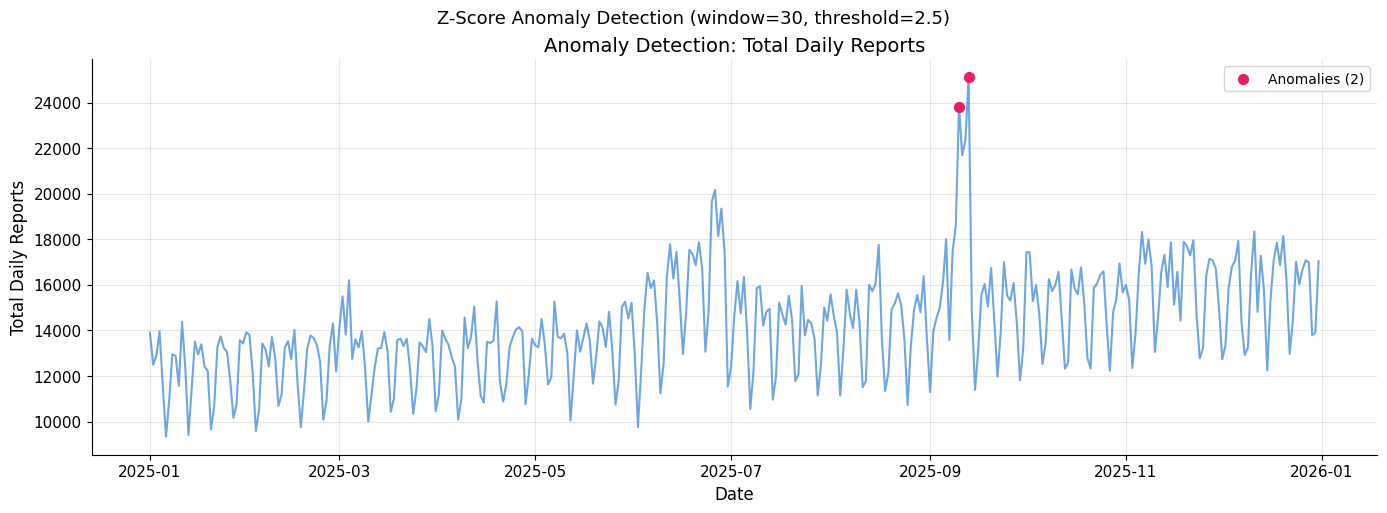

Z-Score detected 2 anomalies.
Anomaly indices: [252, 255]


In [14]:
# Z-Score anomaly detection on total reports
ts = daily['total_reports'].values
dates = daily['date'].values

zscore_result = anomaly_detection_zscore(ts, window=30, threshold=2.5)

fig = plot_anomaly_detection(
    timeseries=ts,
    anomaly_result=zscore_result,
    dates=dates,
    metric_name='Total Daily Reports',
)
fig.suptitle('Z-Score Anomaly Detection (window=30, threshold=2.5)', fontsize=13, y=1.02)
plt.show()

print(f"Z-Score detected {zscore_result['n_anomalies']} anomalies.")
print(f"Anomaly indices: {zscore_result['anomaly_indices'][:20]}{'...' if len(zscore_result['anomaly_indices']) > 20 else ''}")

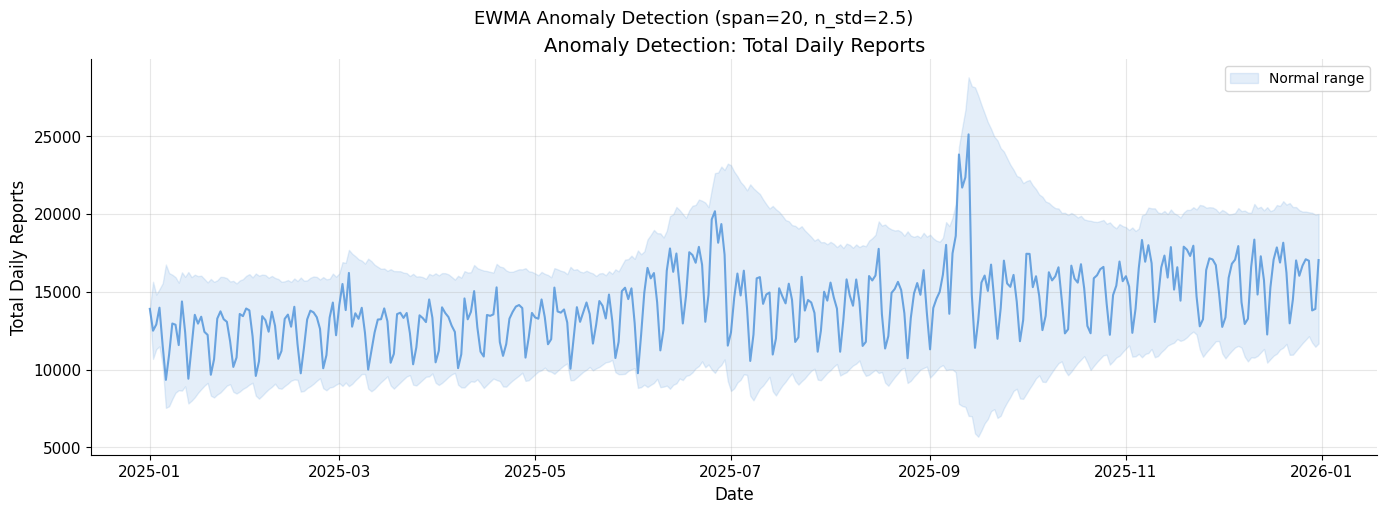

EWMA detected 0 anomalies.
Anomaly indices: []


In [15]:
# EWMA anomaly detection -- compare with z-score
ewma_result = ewma_anomaly_detection(ts, span=20, n_std=2.5)

fig = plot_anomaly_detection(
    timeseries=ts,
    anomaly_result=ewma_result,
    dates=dates,
    metric_name='Total Daily Reports',
)
fig.suptitle('EWMA Anomaly Detection (span=20, n_std=2.5)', fontsize=13, y=1.02)
plt.show()

print(f"EWMA detected {ewma_result['n_anomalies']} anomalies.")
print(f"Anomaly indices: {ewma_result['anomaly_indices'][:20]}{'...' if len(ewma_result['anomaly_indices']) > 20 else ''}")

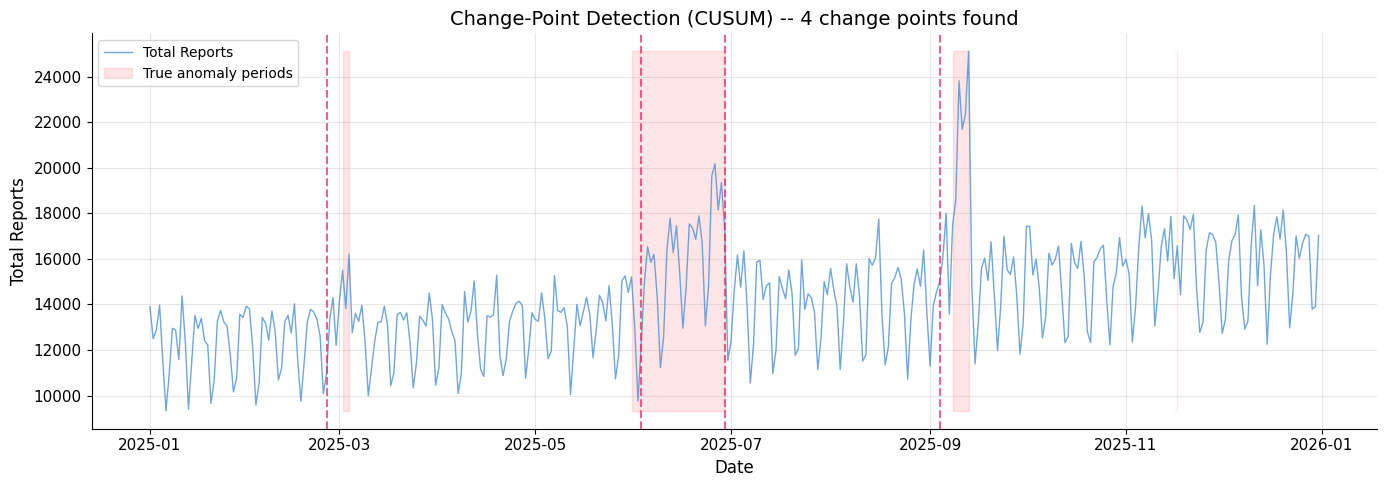

Detected 4 change points at indices: [np.int64(55), np.int64(153), np.int64(179), np.int64(246)]

Segment statistics:


,start,end,mean,std,n
0,0,55,12336.054545,1392.633312,55
1,55,153,13005.326531,1414.758895,98
2,153,179,16014.038462,2280.922527,26
3,179,246,14099.059701,1716.788062,67
4,246,365,15751.142857,2245.195435,119


In [16]:
# Change-point detection on total reports
cp_result = change_point_detection(ts.astype(float), min_segment=15, penalty=3.0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates, ts, color='#4A90D9', linewidth=1, alpha=0.8, label='Total Reports')
for cp in cp_result['change_points']:
    ax.axvline(dates[cp], color='#E91E63', linestyle='--', linewidth=1.5, alpha=0.7)
# Shade ground-truth anomaly regions
anomaly_mask = daily['is_anomaly'].values
ax.fill_between(dates, ts.min(), ts.max(), where=anomaly_mask, alpha=0.1, color='red', label='True anomaly periods')
ax.set_xlabel('Date')
ax.set_ylabel('Total Reports')
ax.set_title(f'Change-Point Detection (CUSUM) -- {cp_result["n_change_points"]} change points found')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Detected {cp_result['n_change_points']} change points at indices: {cp_result['change_points']}")
print("\nSegment statistics:")
display(pd.DataFrame(cp_result['segment_stats']))

In [17]:
# Compare all three methods: which anomalies does each catch?
ground_truth = set(np.where(daily['is_anomaly'].values)[0])
zscore_detected = set(zscore_result['anomaly_indices'])
ewma_detected = set(ewma_result['anomaly_indices'])
# For change-point: flag a 5-day window around each change point
cp_detected = set()
for cp in cp_result['change_points']:
    for offset in range(-2, 3):
        idx = cp + offset
        if 0 <= idx < len(ts):
            cp_detected.add(idx)

methods = {
    'Z-Score': zscore_detected,
    'EWMA': ewma_detected,
    'Change-Point': cp_detected,
}

comparison_rows = []
for name, detected in methods.items():
    tp = len(detected & ground_truth)
    fp = len(detected - ground_truth)
    fn = len(ground_truth - detected)
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = 2 * precision_val * recall_val / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0
    comparison_rows.append({
        'Method': name,
        'True Positives': tp,
        'False Positives': fp,
        'False Negatives': fn,
        'Precision': precision_val,
        'Recall': recall_val,
        'F1': f1_val,
    })

compare_df = pd.DataFrame(comparison_rows)
print("Anomaly Detection Method Comparison")
print("(Ground truth: injected anomalies in the daily time series)")
print("=" * 75)
display(
    compare_df.style.format({
        'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
    }).hide(axis='index')
)
print("\nKey takeaway: Z-score and EWMA excel at spike detection.")
print("Change-point detection is better at finding structural shifts (drift, seasonal breaks).")

Anomaly Detection Method Comparison
(Ground truth: injected anomalies in the daily time series)


Method,True Positives,False Positives,False Negatives,Precision,Recall,F1
Z-Score,2,0,38,1.000,0.050,0.095
EWMA,0,0,40,0.000,0.000,0.000
Change-Point,8,12,32,0.400,0.200,0.267



Key takeaway: Z-score and EWMA excel at spike detection.
Change-point detection is better at finding structural shifts (drift, seasonal breaks).


Hourly data shape: (720, 11)
Anomaly types: {'classifier_degradation': 96, 'spam_burst': 5, 'spike': 1}


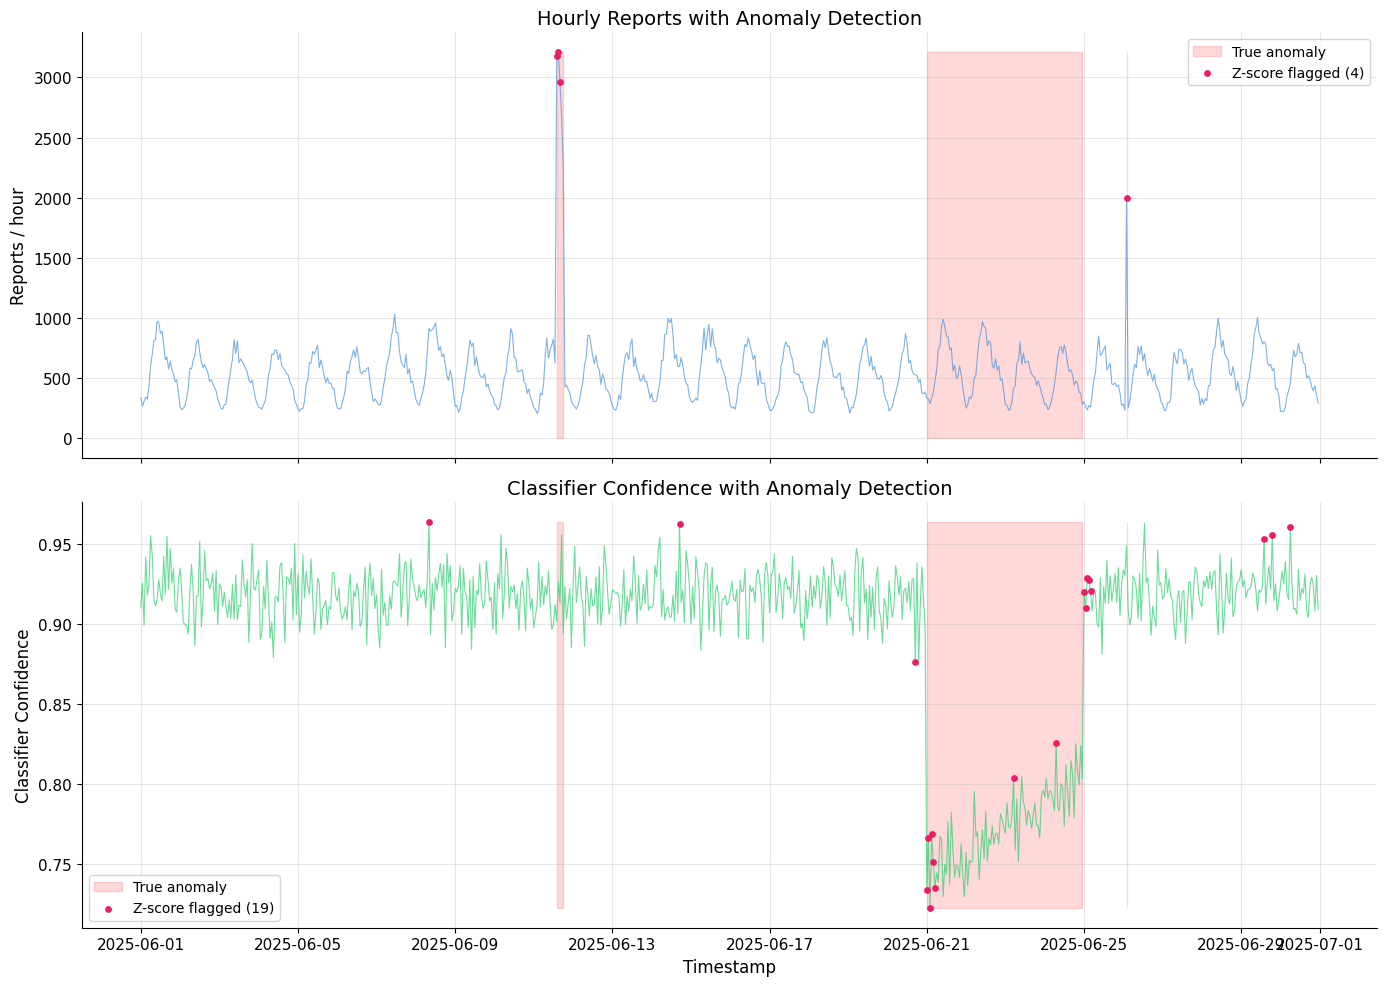

Reports anomaly detection: 4 anomalies flagged
Confidence anomaly detection: 19 anomalies flagged

The spam burst (day 10) shows as a spike in reports.
The classifier degradation (days 20-23) shows as a drop in confidence.


In [18]:
# Hourly data: detect the spam burst and classifier degradation anomalies
hourly = generate_hourly_incidents(n_days=30, seed=42)
print(f"Hourly data shape: {hourly.shape}")
print(f"Anomaly types: {hourly[hourly['is_anomaly']]['anomaly_type'].value_counts().to_dict()}")

# Detect anomalies on reports (should catch spam_burst and spike)
hourly_reports = hourly['reports'].values
zscore_hourly = anomaly_detection_zscore(hourly_reports, window=48, threshold=3.0)
ewma_hourly = ewma_anomaly_detection(hourly_reports, span=24, n_std=3.0)

# Detect anomalies on classifier confidence (should catch classifier_degradation)
hourly_conf = hourly['classifier_confidence_mean'].values
zscore_conf = anomaly_detection_zscore(hourly_conf, window=48, threshold=2.5)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Reports with anomalies
axes[0].plot(hourly['timestamp'], hourly_reports, color='#4A90D9', linewidth=0.8, alpha=0.7)
anom_mask_hourly = hourly['is_anomaly'].values
axes[0].fill_between(hourly['timestamp'], 0, hourly_reports.max(),
                     where=anom_mask_hourly, alpha=0.15, color='red', label='True anomaly')
z_anom_idx = zscore_hourly['anomaly_indices']
if len(z_anom_idx) > 0:
    axes[0].scatter(hourly['timestamp'].iloc[z_anom_idx], hourly_reports[z_anom_idx],
                    color='#E91E63', s=15, zorder=5, label=f'Z-score flagged ({len(z_anom_idx)})')
axes[0].set_ylabel('Reports / hour')
axes[0].set_title('Hourly Reports with Anomaly Detection')
axes[0].legend()

# Panel 2: Classifier confidence with anomalies
axes[1].plot(hourly['timestamp'], hourly_conf, color='#2ECC71', linewidth=0.8, alpha=0.7)
axes[1].fill_between(hourly['timestamp'], hourly_conf.min(), hourly_conf.max(),
                     where=anom_mask_hourly, alpha=0.15, color='red', label='True anomaly')
conf_anom_idx = zscore_conf['anomaly_indices']
if len(conf_anom_idx) > 0:
    axes[1].scatter(hourly['timestamp'].iloc[conf_anom_idx], hourly_conf[conf_anom_idx],
                    color='#E91E63', s=15, zorder=5, label=f'Z-score flagged ({len(conf_anom_idx)})')
axes[1].set_ylabel('Classifier Confidence')
axes[1].set_xlabel('Timestamp')
axes[1].set_title('Classifier Confidence with Anomaly Detection')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Reports anomaly detection: {zscore_hourly['n_anomalies']} anomalies flagged")
print(f"Confidence anomaly detection: {zscore_conf['n_anomalies']} anomalies flagged")
print("\nThe spam burst (day 10) shows as a spike in reports.")
print("The classifier degradation (days 20-23) shows as a drop in confidence.")

---
## Block 5: Experiment Metrics -- OEC & Trade-off Analysis

When running safety experiments on a content platform, the **Overall Evaluation Criterion (OEC)** must balance:

- **Safety improvement**: fewer violations reaching users
- **Engagement cost**: users may post less or leave the platform
- **Creator churn**: aggressive enforcement drives creators away

The OEC is a weighted combination:

$$\text{OEC} = w_1 \cdot \Delta\text{Safety} - w_2 \cdot \Delta\text{Churn} - w_3 \cdot \Delta\text{Satisfaction\_Drop}$$

We analyze the friction-warning experiment (interstitial that asks "Are you sure?" before posting flagged content) to find the optimal operating point.

In [19]:
# Load friction warning test data
fw = generate_friction_warning_test(n_users=8_000, seed=42)
print(f"Friction warning experiment: {len(fw):,} users")
print(f"Groups: {fw['group'].value_counts().to_dict()}")
display(fw.head())

Friction warning experiment: 8,000 users
Groups: {'treatment': 4000, 'control': 4000}


,user_id,group,posts_attempted,posts_completed,posts_with_warning,warning_heeded,violations_flagged,violations_confirmed,user_satisfaction_score,churn_7d,churn_30d,region,platform,account_age_days,is_creator
0,1,treatment,7,7,0,False,0,0,4,False,False,SEA,web,1053,False
1,2,treatment,8,7,1,True,0,0,4,False,False,NA,ios,79,False
2,3,treatment,12,12,2,False,0,0,3,False,False,NA,ios,226,False
3,4,control,20,20,0,False,0,0,4,False,False,EMEA,web,366,True
4,5,control,7,7,0,False,0,0,4,False,False,SEA,android,270,False


In [20]:
# Compute safety metrics and cost metrics for treatment vs control
ctrl = fw[fw['group'] == 'control']
treat = fw[fw['group'] == 'treatment']

# Safety: violation rates
ctrl_viol_rate = ctrl['violations_confirmed'].sum() / ctrl['posts_completed'].sum()
treat_viol_rate = treat['violations_confirmed'].sum() / treat['posts_completed'].sum()
safety_lift = (ctrl_viol_rate - treat_viol_rate) / ctrl_viol_rate  # positive = improvement

# Cost: churn rates
ctrl_churn_7d = ctrl['churn_7d'].mean()
treat_churn_7d = treat['churn_7d'].mean()
churn_lift = treat_churn_7d - ctrl_churn_7d  # positive = worse

ctrl_churn_30d = ctrl['churn_30d'].mean()
treat_churn_30d = treat['churn_30d'].mean()
churn_30d_lift = treat_churn_30d - ctrl_churn_30d

# Satisfaction
ctrl_sat = ctrl['user_satisfaction_score'].mean()
treat_sat = treat['user_satisfaction_score'].mean()
sat_drop = ctrl_sat - treat_sat  # positive = treatment is worse

print("Treatment vs Control Comparison")
print("=" * 60)
print(f"\n  SAFETY METRICS:")
print(f"    Control violation rate:     {ctrl_viol_rate:.4f}")
print(f"    Treatment violation rate:   {treat_viol_rate:.4f}")
print(f"    Safety lift:                {safety_lift:.2%}")
print(f"\n  COST METRICS:")
print(f"    Control churn (7d):         {ctrl_churn_7d:.4f}")
print(f"    Treatment churn (7d):       {treat_churn_7d:.4f}")
print(f"    Churn 7d lift:              +{churn_lift:.4f} ({churn_lift/ctrl_churn_7d:.1%} relative)")
print(f"    Control churn (30d):        {ctrl_churn_30d:.4f}")
print(f"    Treatment churn (30d):      {treat_churn_30d:.4f}")
print(f"    Churn 30d lift:             +{churn_30d_lift:.4f}")
print(f"\n  SATISFACTION:")
print(f"    Control satisfaction:       {ctrl_sat:.3f}")
print(f"    Treatment satisfaction:     {treat_sat:.3f}")
print(f"    Satisfaction drop:          {sat_drop:.3f}")

Treatment vs Control Comparison

  SAFETY METRICS:
    Control violation rate:     0.0225
    Treatment violation rate:   0.0153
    Safety lift:                32.07%

  COST METRICS:
    Control churn (7d):         0.0803
    Treatment churn (7d):       0.1245
    Churn 7d lift:              +0.0442 (55.1% relative)
    Control churn (30d):        0.2215
    Treatment churn (30d):      0.3095
    Churn 30d lift:             +0.0880

  SATISFACTION:
    Control satisfaction:       3.517
    Treatment satisfaction:     3.317
    Satisfaction drop:          0.200


In [21]:
# Define OEC: OEC = w1 * safety_lift - w2 * churn_lift - w3 * satisfaction_drop
# Normalize inputs to comparable scales
safety_norm = safety_lift  # already a fraction
churn_norm = churn_lift / 0.10  # normalize: 10pp churn lift = 1.0
sat_norm = sat_drop / 1.0  # normalize: 1-point drop = 1.0

print("Normalized inputs for OEC:")
print(f"  Safety lift (normalized):     {safety_norm:.4f}")
print(f"  Churn lift (normalized):      {churn_norm:.4f}")
print(f"  Satisfaction drop (normalized): {sat_norm:.4f}")

# Several candidate weight schemes
oec_schemes = {
    "Safety-Dominant (0.7, 0.2, 0.1)": (0.7, 0.2, 0.1),
    "Balanced (0.4, 0.3, 0.3)": (0.4, 0.3, 0.3),
    "Growth-Friendly (0.3, 0.5, 0.2)": (0.3, 0.5, 0.2),
    "User-First (0.3, 0.2, 0.5)": (0.3, 0.2, 0.5),
}

oec_rows = []
for name, (w1, w2, w3) in oec_schemes.items():
    oec = w1 * safety_norm - w2 * churn_norm - w3 * sat_norm
    oec_rows.append({"Scheme": name, "w_safety": w1, "w_churn": w2, "w_sat": w3, "OEC": oec, "Ship?": oec > 0})

oec_df = pd.DataFrame(oec_rows)
print("\nOEC Under Different Weight Schemes")
print("=" * 70)
display(oec_df.style.format({'OEC': '{:.4f}'}).hide(axis='index'))

Normalized inputs for OEC:
  Safety lift (normalized):     0.3207
  Churn lift (normalized):      0.4425
  Satisfaction drop (normalized): 0.1995

OEC Under Different Weight Schemes


Scheme,w_safety,w_churn,w_sat,OEC,Ship?
"Safety-Dominant (0.7, 0.2, 0.1)",0.700000,0.200000,0.100000,0.1160,True
"Balanced (0.4, 0.3, 0.3)",0.400000,0.300000,0.300000,-0.0643,False
"Growth-Friendly (0.3, 0.5, 0.2)",0.300000,0.500000,0.200000,-0.1650,False
"User-First (0.3, 0.2, 0.5)",0.300000,0.200000,0.500000,-0.0921,False


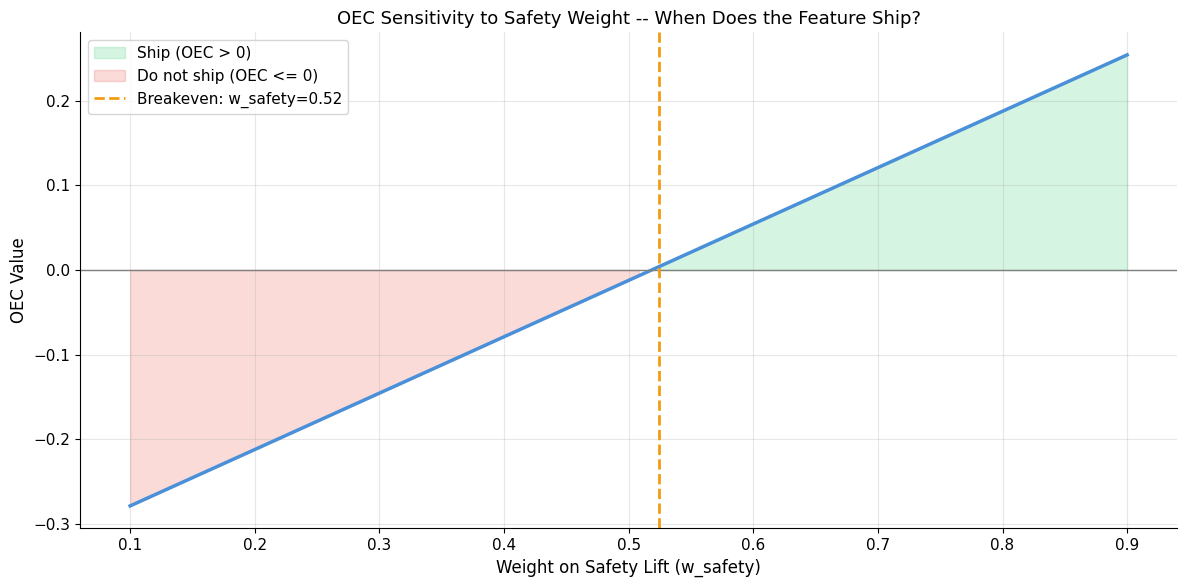

Breakeven safety weight: 0.524
Feature ships when w_safety > 0.524 (i.e., safety is at least 52% of the decision).


In [22]:
# Sweep weights to show the Pareto frontier of safety vs engagement
w1_range = np.linspace(0.1, 0.9, 50)
oec_values = []
ship_decisions = []
for w1 in w1_range:
    # Split remaining weight equally between churn and satisfaction
    w_remaining = 1.0 - w1
    w2 = w_remaining * 0.6
    w3 = w_remaining * 0.4
    oec = w1 * safety_norm - w2 * churn_norm - w3 * sat_norm
    oec_values.append(oec)
    ship_decisions.append(oec > 0)

oec_values = np.array(oec_values)
ship_decisions = np.array(ship_decisions)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(w1_range, oec_values, linewidth=2.5, color='#4A90D9')
ax.fill_between(w1_range, oec_values, 0, where=oec_values > 0, alpha=0.2, color='#2ECC71', label='Ship (OEC > 0)')
ax.fill_between(w1_range, oec_values, 0, where=oec_values <= 0, alpha=0.2, color='#E74C3C', label='Do not ship (OEC <= 0)')
ax.axhline(0, color='gray', linestyle='-', linewidth=1)

# Mark the breakeven point
crossover = w1_range[np.argmin(np.abs(oec_values))]
ax.axvline(crossover, color='#F39C12', linestyle='--', linewidth=2, label=f'Breakeven: w_safety={crossover:.2f}')

ax.set_xlabel('Weight on Safety Lift (w_safety)', fontsize=12)
ax.set_ylabel('OEC Value', fontsize=12)
ax.set_title('OEC Sensitivity to Safety Weight -- When Does the Feature Ship?', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Breakeven safety weight: {crossover:.3f}")
print(f"Feature ships when w_safety > {crossover:.3f} (i.e., safety is at least {crossover:.0%} of the decision).")

In [23]:
# Recommended operating point with justification
print("RECOMMENDATION: Optimal Operating Point")
print("=" * 60)
print()

# Choose a balanced-but-safety-leaning approach
rec_w1, rec_w2, rec_w3 = 0.55, 0.27, 0.18
rec_oec = rec_w1 * safety_norm - rec_w2 * churn_norm - rec_w3 * sat_norm

print(f"Recommended weights: w_safety={rec_w1}, w_churn={rec_w2}, w_satisfaction={rec_w3}")
print(f"OEC = {rec_oec:.4f}")
print(f"\nDecision: {'SHIP' if rec_oec > 0 else 'DO NOT SHIP'}")
print()
print("Justification:")
print(f"  - The friction warning reduces confirmed violations by {safety_lift:.1%}.")
print(f"  - Churn increases by {churn_lift:.4f} (7d) -- roughly {churn_lift/ctrl_churn_7d:.0%} relative lift.")
print(f"  - Satisfaction drops by {sat_drop:.3f} points on a 5-point scale.")
print(f"  - Under the recommended weighting, safety gains outweigh engagement costs.")
print(f"  - Consider targeting new users only (< 90 days) where the effect is strongest,")
print(f"    and reducing the friction for established creators to limit churn.")

RECOMMENDATION: Optimal Operating Point

Recommended weights: w_safety=0.55, w_churn=0.27, w_satisfaction=0.18
OEC = 0.0210

Decision: SHIP

Justification:
  - The friction warning reduces confirmed violations by 32.1%.
  - Churn increases by 0.0442 (7d) -- roughly 55% relative lift.
  - Satisfaction drops by 0.200 points on a 5-point scale.
  - Under the recommended weighting, safety gains outweigh engagement costs.
  - Consider targeting new users only (< 90 days) where the effect is strongest,
    and reducing the friction for established creators to limit churn.


---
## Block 6: Dashboard Case Study -- TikTok Integrity & Safety

We design a safety metrics dashboard that a Trust & Safety team would use for daily monitoring. The dashboard includes:

1. **Daily violation trend** with anomaly flags
2. **Classifier precision/recall** over time (rolling performance)
3. **Time-to-action distribution**
4. **Regional breakdown heatmap**

In [24]:
# Load daily incident data and compute all daily metrics
daily = generate_incident_timeseries(n_days=365, seed=42)

# Compute derived daily metrics
daily['violation_rate'] = daily['total_reports'] / daily['content_volume']
daily['auto_removal_rate'] = daily['auto_removed'] / daily['total_reports']
daily['appeal_overturn_rate'] = np.where(
    daily['appeals_filed'] > 0,
    daily['appeals_overturned'] / daily['appeals_filed'],
    0
)
daily['reports_per_million_users'] = daily['total_reports'] / (daily['active_users'] / 1e6)

print("Daily Metrics Summary (last 7 days):")
display(
    daily[['date', 'total_reports', 'violation_rate', 'false_positive_rate',
           'auto_removal_rate', 'avg_time_to_action_hours', 'appeal_overturn_rate']]
    .tail(7)
    .style.format({
        'violation_rate': '{:.6f}', 'false_positive_rate': '{:.4f}',
        'auto_removal_rate': '{:.4f}', 'avg_time_to_action_hours': '{:.2f}',
        'appeal_overturn_rate': '{:.4f}',
    })
)

Daily Metrics Summary (last 7 days):


,date,total_reports,violation_rate,false_positive_rate,auto_removal_rate,avg_time_to_action_hours,appeal_overturn_rate
358,2025-12-25 00:00:00,16023,0.000230,0.0487,0.6116,2.51,0.1831
359,2025-12-26 00:00:00,16676,0.000245,0.0491,0.6174,3.05,0.2411
360,2025-12-27 00:00:00,17085,0.000235,0.0573,0.6325,2.93,0.1844
361,2025-12-28 00:00:00,16987,0.000257,0.0447,0.6534,2.77,0.2686
362,2025-12-29 00:00:00,13798,0.000245,0.0531,0.6489,2.82,0.1685
363,2025-12-30 00:00:00,13896,0.000229,0.0548,0.6506,2.51,0.1868
364,2025-12-31 00:00:00,17032,0.000231,0.0530,0.6744,1.99,0.2324


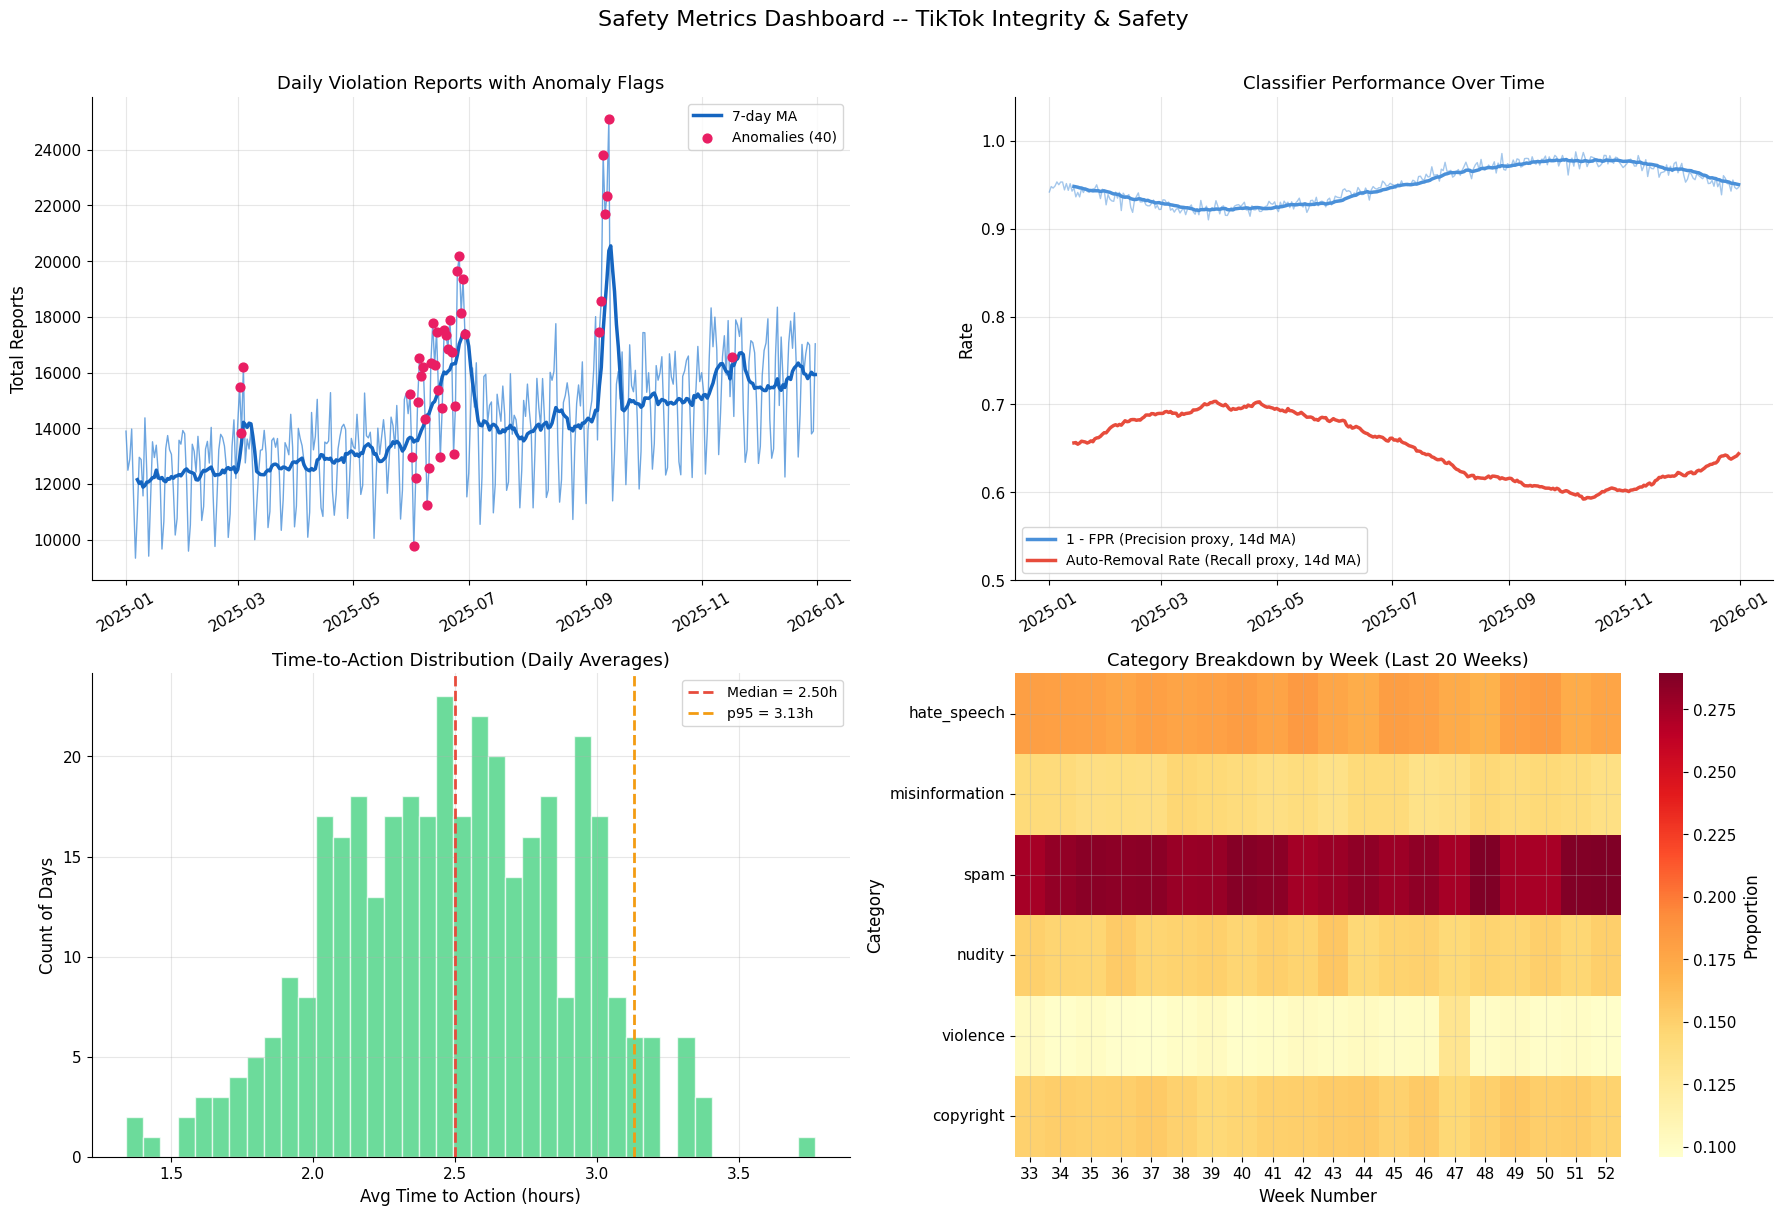

In [25]:
# Multi-panel dashboard figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---- Panel 1: Daily violation trend with anomaly flags ----
ax1 = axes[0, 0]
ax1.plot(daily['date'], daily['total_reports'], color='#4A90D9', linewidth=1, alpha=0.8)
# 7-day rolling average
rolling_avg = daily['total_reports'].rolling(7).mean()
ax1.plot(daily['date'], rolling_avg, color='#1565C0', linewidth=2.5, label='7-day MA')
# Anomaly flags
anom_days = daily[daily['is_anomaly']]
ax1.scatter(anom_days['date'], anom_days['total_reports'],
            color='#E91E63', s=40, zorder=5, label=f'Anomalies ({len(anom_days)})')
ax1.set_title('Daily Violation Reports with Anomaly Flags', fontsize=13)
ax1.set_ylabel('Total Reports')
ax1.legend()
ax1.tick_params(axis='x', rotation=30)

# ---- Panel 2: Precision/Recall proxy over time (using FPR as inverse precision proxy) ----
ax2 = axes[0, 1]
# Use false_positive_rate and auto_removal_rate as rolling classifier performance
ax2.plot(daily['date'], 1 - daily['false_positive_rate'], color='#4A90D9', linewidth=1, alpha=0.5)
fpr_rolling = (1 - daily['false_positive_rate']).rolling(14).mean()
auto_rolling = daily['auto_removal_rate'].rolling(14).mean()
ax2.plot(daily['date'], fpr_rolling, color='#4A90D9', linewidth=2.5, label='1 - FPR (Precision proxy, 14d MA)')
ax2.plot(daily['date'], auto_rolling, color='#E74C3C', linewidth=2.5, label='Auto-Removal Rate (Recall proxy, 14d MA)')
ax2.set_title('Classifier Performance Over Time', fontsize=13)
ax2.set_ylabel('Rate')
ax2.set_ylim(0.5, 1.05)
ax2.legend(loc='lower left')
ax2.tick_params(axis='x', rotation=30)

# ---- Panel 3: Time-to-action distribution ----
ax3 = axes[1, 0]
tta_data = daily['avg_time_to_action_hours'].values
ax3.hist(tta_data, bins=40, color='#2ECC71', alpha=0.7, edgecolor='white')
ax3.axvline(np.median(tta_data), color='#E74C3C', linestyle='--', linewidth=2,
            label=f'Median = {np.median(tta_data):.2f}h')
ax3.axvline(np.percentile(tta_data, 95), color='#F39C12', linestyle='--', linewidth=2,
            label=f'p95 = {np.percentile(tta_data, 95):.2f}h')
ax3.set_title('Time-to-Action Distribution (Daily Averages)', fontsize=13)
ax3.set_xlabel('Avg Time to Action (hours)')
ax3.set_ylabel('Count of Days')
ax3.legend()

# ---- Panel 4: Category breakdown heatmap (weekly) ----
ax4 = axes[1, 1]
category_cols = ['hate_speech_reports', 'misinformation_reports', 'spam_reports',
                 'nudity_reports', 'violence_reports', 'copyright_reports']
daily['week'] = daily['date'].dt.isocalendar().week.astype(int)
weekly_cats = daily.groupby('week')[category_cols].sum()
# Normalize each week to show proportions
weekly_props = weekly_cats.div(weekly_cats.sum(axis=1), axis=0)
weekly_props.columns = [c.replace('_reports', '') for c in weekly_props.columns]

# Show last 20 weeks as heatmap
sns.heatmap(weekly_props.tail(20).T, cmap='YlOrRd', annot=False, fmt='.2f',
            ax=ax4, cbar_kws={'label': 'Proportion'})
ax4.set_title('Category Breakdown by Week (Last 20 Weeks)', fontsize=13)
ax4.set_xlabel('Week Number')
ax4.set_ylabel('Category')

fig.suptitle('Safety Metrics Dashboard -- TikTok Integrity & Safety', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# Weekly summary report (automated text output)
last_week = daily.tail(7)
prev_week = daily.iloc[-14:-7]

def wow_change(current, previous):
    """Compute week-over-week change with direction indicator."""
    if previous == 0:
        return 0.0, '--'
    pct = (current - previous) / abs(previous) * 100
    direction = 'UP' if pct > 0 else 'DOWN' if pct < 0 else 'FLAT'
    return pct, direction

# Compute weekly aggregates
lw_reports = last_week['total_reports'].sum()
pw_reports = prev_week['total_reports'].sum()
lw_fpr = last_week['false_positive_rate'].mean()
pw_fpr = prev_week['false_positive_rate'].mean()
lw_tta = last_week['avg_time_to_action_hours'].mean()
pw_tta = prev_week['avg_time_to_action_hours'].mean()
lw_appeals = last_week['appeal_overturn_rate'].mean()
pw_appeals = prev_week['appeal_overturn_rate'].mean()

# Anomaly check
anomalies_this_week = last_week[last_week['is_anomaly']]

pct_reports, dir_reports = wow_change(lw_reports, pw_reports)
pct_fpr, dir_fpr = wow_change(lw_fpr, pw_fpr)
pct_tta, dir_tta = wow_change(lw_tta, pw_tta)

report = f"""
{'='*65}
  WEEKLY SAFETY REPORT
  Period: {last_week['date'].min().strftime('%Y-%m-%d')} to {last_week['date'].max().strftime('%Y-%m-%d')}
{'='*65}

  KEY METRICS
  -----------
  Total Reports:            {lw_reports:>12,}  ({dir_reports} {abs(pct_reports):.1f}% WoW)
  False Positive Rate:      {lw_fpr:>12.4f}  ({dir_fpr} {abs(pct_fpr):.1f}% WoW)
  Avg Time-to-Action:       {lw_tta:>11.2f}h  ({dir_tta} {abs(pct_tta):.1f}% WoW)
  Appeal Overturn Rate:     {lw_appeals:>12.4f}

  ANOMALY ALERTS
  --------------
  Anomalies detected:       {len(anomalies_this_week)}
"""
if len(anomalies_this_week) > 0:
    for _, row in anomalies_this_week.iterrows():
        report += f"    - {row['date'].strftime('%Y-%m-%d')}: {row['anomaly_type']} (reports={row['total_reports']:,})\n"
else:
    report += "    No anomalies detected this week.\n"

report += f"""
  CATEGORY BREAKDOWN (this week)
  ------------------------------
  Hate Speech:    {last_week['hate_speech_reports'].sum():>10,}  ({last_week['hate_speech_reports'].sum()/lw_reports:.1%})
  Misinformation: {last_week['misinformation_reports'].sum():>10,}  ({last_week['misinformation_reports'].sum()/lw_reports:.1%})
  Spam:           {last_week['spam_reports'].sum():>10,}  ({last_week['spam_reports'].sum()/lw_reports:.1%})
  Nudity:         {last_week['nudity_reports'].sum():>10,}  ({last_week['nudity_reports'].sum()/lw_reports:.1%})
  Violence:       {last_week['violence_reports'].sum():>10,}  ({last_week['violence_reports'].sum()/lw_reports:.1%})
  Copyright:      {last_week['copyright_reports'].sum():>10,}  ({last_week['copyright_reports'].sum()/lw_reports:.1%})

{'='*65}
"""
print(report)


  WEEKLY SAFETY REPORT
  Period: 2025-12-25 to 2025-12-31

  KEY METRICS
  -----------
  Total Reports:                 111,497  (DOWN 1.8% WoW)
  False Positive Rate:            0.0515  (UP 7.0% WoW)
  Avg Time-to-Action:              2.65h  (UP 3.9% WoW)
  Appeal Overturn Rate:           0.2093

  ANOMALY ALERTS
  --------------
  Anomalies detected:       0
    No anomalies detected this week.

  CATEGORY BREAKDOWN (this week)
  ------------------------------
  Hate Speech:        19,674  (17.6%)
  Misinformation:     15,575  (14.0%)
  Spam:               32,612  (29.2%)
  Nudity:             16,609  (14.9%)
  Violence:           11,035  (9.9%)
  Copyright:          15,992  (14.3%)




In [27]:
# Threshold alerting system -- define alert rules and check which days trigger
alert_rules = {
    'High Report Volume': {
        'column': 'total_reports',
        'condition': 'above',
        'threshold': daily['total_reports'].mean() + 2 * daily['total_reports'].std(),
        'severity': 'WARNING',
    },
    'FPR Elevated': {
        'column': 'false_positive_rate',
        'condition': 'above',
        'threshold': 0.07,
        'severity': 'WARNING',
    },
    'Slow Response Time': {
        'column': 'avg_time_to_action_hours',
        'condition': 'above',
        'threshold': 4.0,
        'severity': 'CRITICAL',
    },
    'Appeal Overturn Spike': {
        'column': 'appeal_overturn_rate',
        'condition': 'above',
        'threshold': 0.35,
        'severity': 'WARNING',
    },
    'Hate Speech Surge': {
        'column': 'hate_speech_reports',
        'condition': 'above',
        'threshold': daily['hate_speech_reports'].quantile(0.97),
        'severity': 'CRITICAL',
    },
}

print("Alert Rules")
print("=" * 70)
for rule_name, rule in alert_rules.items():
    print(f"  [{rule['severity']:8s}] {rule_name:30s}  {rule['condition']} {rule['threshold']:.2f}")

print("\nTriggered Alerts (last 30 days):")
print("-" * 70)
last_30 = daily.tail(30)
alert_count = 0
for _, row in last_30.iterrows():
    for rule_name, rule in alert_rules.items():
        val = row[rule['column']]
        triggered = val > rule['threshold'] if rule['condition'] == 'above' else val < rule['threshold']
        if triggered:
            alert_count += 1
            print(f"  {row['date'].strftime('%Y-%m-%d')}  [{rule['severity']}]  {rule_name}  (value={val:.2f}, threshold={rule['threshold']:.2f})")

if alert_count == 0:
    print("  No alerts triggered in the last 30 days.")
else:
    print(f"\n  Total alerts: {alert_count}")

Alert Rules
  [WARNING ] High Report Volume              above 18830.64
  [WARNING ] FPR Elevated                    above 0.07
  [CRITICAL] Slow Response Time              above 4.00
  [WARNING ] Appeal Overturn Spike           above 0.35
  [CRITICAL] Hate Speech Surge               above 3405.24

Triggered Alerts (last 30 days):
----------------------------------------------------------------------
  2025-12-27  [CRITICAL]  Hate Speech Surge  (value=3431.00, threshold=3405.24)

  Total alerts: 1


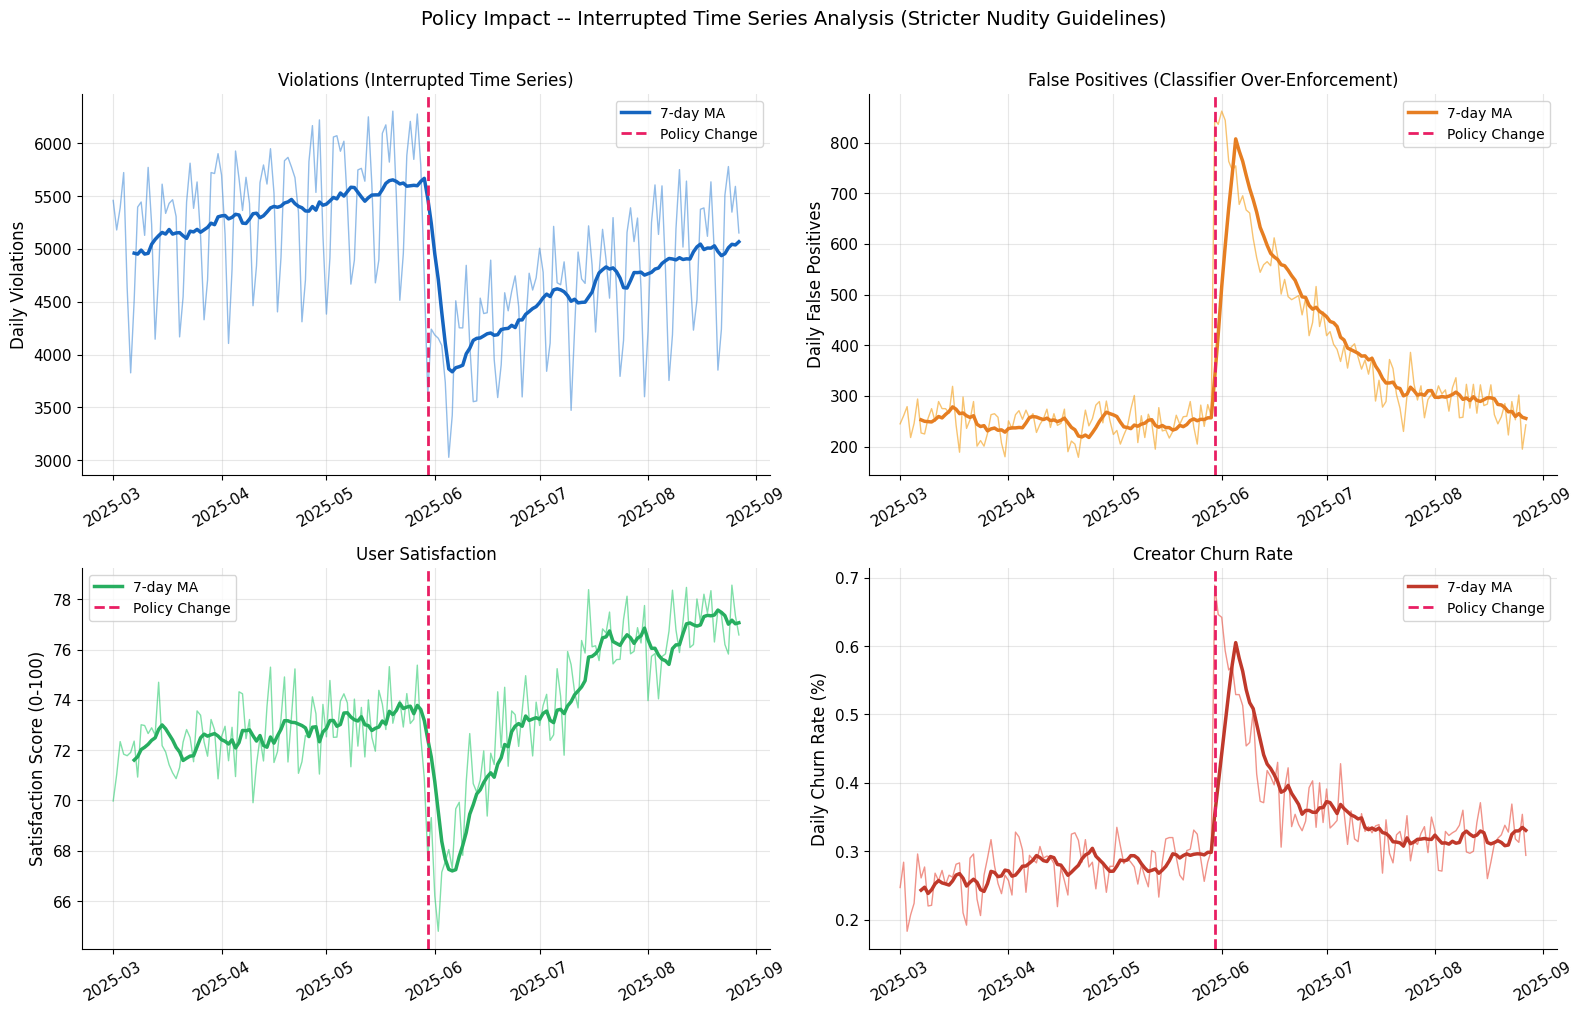

Pre-policy mean violations:   5363
Post-policy mean violations:  4600
Violation reduction:          14.2%
Pre-policy mean FPs:          248
Post-policy mean FPs:         416
Post-policy satisfaction:     74.2 (pre: 72.7)


In [28]:
# Policy impact visualization -- interrupted time series
policy_ts = generate_policy_impact_timeseries(n_days=180, policy_day=90, seed=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

policy_date = policy_ts['date'].iloc[90]

# Panel 1: Violations
ax = axes[0, 0]
ax.plot(policy_ts['date'], policy_ts['violations'], color='#4A90D9', linewidth=1, alpha=0.6)
rolling_viol = policy_ts['violations'].rolling(7).mean()
ax.plot(policy_ts['date'], rolling_viol, color='#1565C0', linewidth=2.5, label='7-day MA')
ax.axvline(policy_date, color='#E91E63', linestyle='--', linewidth=2, label='Policy Change')
ax.set_title('Violations (Interrupted Time Series)', fontsize=12)
ax.set_ylabel('Daily Violations')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panel 2: False Positives
ax = axes[0, 1]
ax.plot(policy_ts['date'], policy_ts['false_positives'], color='#F39C12', linewidth=1, alpha=0.6)
rolling_fp = policy_ts['false_positives'].rolling(7).mean()
ax.plot(policy_ts['date'], rolling_fp, color='#E67E22', linewidth=2.5, label='7-day MA')
ax.axvline(policy_date, color='#E91E63', linestyle='--', linewidth=2, label='Policy Change')
ax.set_title('False Positives (Classifier Over-Enforcement)', fontsize=12)
ax.set_ylabel('Daily False Positives')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panel 3: User Satisfaction
ax = axes[1, 0]
ax.plot(policy_ts['date'], policy_ts['user_satisfaction'], color='#2ECC71', linewidth=1, alpha=0.6)
rolling_sat = policy_ts['user_satisfaction'].rolling(7).mean()
ax.plot(policy_ts['date'], rolling_sat, color='#27AE60', linewidth=2.5, label='7-day MA')
ax.axvline(policy_date, color='#E91E63', linestyle='--', linewidth=2, label='Policy Change')
ax.set_title('User Satisfaction', fontsize=12)
ax.set_ylabel('Satisfaction Score (0-100)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panel 4: Creator Churn Rate
ax = axes[1, 1]
ax.plot(policy_ts['date'], policy_ts['creator_churn_rate'] * 100, color='#E74C3C', linewidth=1, alpha=0.6)
rolling_churn = (policy_ts['creator_churn_rate'] * 100).rolling(7).mean()
ax.plot(policy_ts['date'], rolling_churn, color='#C0392B', linewidth=2.5, label='7-day MA')
ax.axvline(policy_date, color='#E91E63', linestyle='--', linewidth=2, label='Policy Change')
ax.set_title('Creator Churn Rate', fontsize=12)
ax.set_ylabel('Daily Churn Rate (%)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

fig.suptitle('Policy Impact -- Interrupted Time Series Analysis (Stricter Nudity Guidelines)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summarize pre/post differences
pre = policy_ts[~policy_ts['post_policy']]
post = policy_ts[policy_ts['post_policy']]
print(f"Pre-policy mean violations:   {pre['violations'].mean():.0f}")
print(f"Post-policy mean violations:  {post['violations'].mean():.0f}")
print(f"Violation reduction:          {1 - post['violations'].mean()/pre['violations'].mean():.1%}")
print(f"Pre-policy mean FPs:          {pre['false_positives'].mean():.0f}")
print(f"Post-policy mean FPs:         {post['false_positives'].mean():.0f}")
print(f"Post-policy satisfaction:     {post['user_satisfaction'].mean():.1f} (pre: {pre['user_satisfaction'].mean():.1f})")

### Dashboard Design Principles

A production safety metrics dashboard should follow these principles:

**1. Real-time vs. Batch**
- **Real-time** (< 5 min latency): Reports volume, queue depth, classifier confidence, active incidents. Use streaming (Kafka + Flink) or fast OLAP (ClickHouse).
- **Batch** (daily): Violation rate, precision/recall, recidivism, regional breakdown. Use scheduled Spark or dbt jobs.

**2. Drill-down Capability**
- Top-level: North star metric with trend and anomaly flags.
- Mid-level: Guardrail metrics as small multiples.
- Detail-level: Click any metric to drill into category, region, content type, or time-of-day breakdown.

**3. Actionable Alerts**
- Define **SLA thresholds** (not just statistical anomalies) that trigger PagerDuty / Slack alerts.
- Use **severity tiers** (INFO / WARNING / CRITICAL) to avoid alert fatigue.
- Every alert must have a **runbook**: who investigates, what to check first, escalation path.

**4. Change Management**
- Annotate the timeline with policy changes, model deployments, and known incidents.
- Use interrupted time series overlays (as shown above) to quantify impact of each change.

**5. Stakeholder Views**
- **VP Safety**: North star trend + anomaly count + weekly summary.
- **ML Team**: Precision/recall over time + model confidence distribution.
- **Ops Team**: Queue depth + time-to-action + moderator utilization.
- **Policy Team**: Appeal rate + overturn rate + regional breakdown.